# Image Sonification with Synthesizer 
Color Space Parameters as Synthesizer Parameters



#### Required Modules


Image processing
- Python OpenCV (https://pypi.org/project/opencv-python/)
- Skimage (https://scikit-image.org/)
  
github repo
- gilbert (https://github.com/jakubcerveny/gilbert)

Should be default (?)
- matplotlib
- numpy
- scipy

In [1]:
#general imports, makes life easier
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#local imports
# from Oscillator_simple import Oscillator
# from Oscillator_simple import frequency_gen
# from Oscillator_simple import generate_sample
# from Oscillator_simple import saturation_lowpass

# from Reader import Image_read #p.s. this module needs the following repo https://github.com/jakubcerveny/gilbert

In [3]:
#display imports
from IPython.display import Audio
from IPython.display import display

def display_sound (wave, show_waveform = True, sample_rate = 44100, cut_frame = None, title=None, Normalize=False):
    time = np.linspace(0, len(wave)/sample_rate, len(wave))
    if show_waveform:
        plt.plot(time, wave)
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (arbitrary unit)')
        plt.title(title)
        
        try:
            plt.xlim(cut_frame[0], cut_frame[1])
        except TypeError:
            pass
            
        plt.show() #prolly should add this later, but oh well...
    display(Audio(wave, rate = sample_rate, autoplay=False, normalize=Normalize))

## Part A - Sonification Method

Before we jump into the tutorial, let's take a quick moment for us to explain square wave: our main waveform.

### A.1 - Anatomy of a square wave (Abridged)

Square wave can be described by various methods. But now, we want to consider the square wave equation as a sign function of a sine wave $$x(t)=sgn(sin(2\pi ft))$$ 

The following graphs the sine wave and the corresponding square wave sign with a frequency of 1.

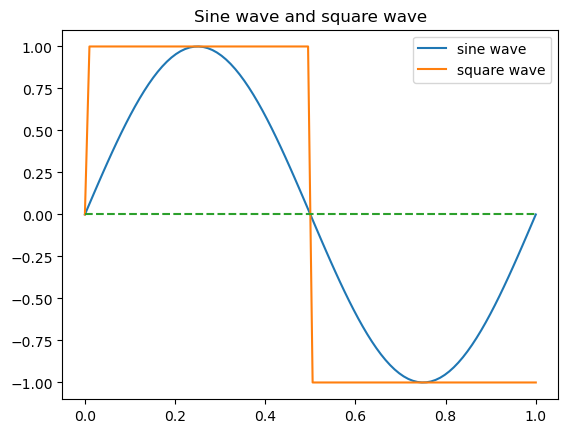

In [4]:
def sine_wave (t, freq = 1):
    return np.sin(2*np.pi*freq*t)

def square_wave (t, freq = 1):
    return np.sign(sine_wave(t, freq))

t = np.linspace(0, 1, num=100)
plt.title("Sine wave and square wave")
plt.plot(t, sine_wave(t), label="sine wave")
plt.plot(t, square_wave(t), label = "square wave")
plt.plot(t, np.zeros_like(t), linestyle='--')
plt.legend()
plt.show()

Notice that the square wave generated from a sine wave have an equal high period and low period, a duty cycle of 50%. By redefining the square wave equation as a piecewise equation, the square wave equation can be expressed as 
$$ x(t)=   \left\{
\begin{array}{ll}
      1 & 2\pi ft \mod 2\pi \le \pi \\
      -1  & 2\pi ft \mod 2\pi > \pi \\
\end{array} 
\right.  $$

Considering a single cycle at a given frequency ($0\le\phi \le 1$; where phase $\phi = 2\pi ft $): 

$$ x(\phi)=   \left\{
\begin{array}{ll}
      1 & \phi \mod 1 \le 0.5 \\
      -1  & \phi \mod 1 > 0.5 \\
\end{array} 
\right.  $$

For uneven square wave, we introduce duty cycle where $ 0 \le D \le 1$, therefore the equation for a single cycle becomes
$$ x(\phi)=   \left\{
\begin{array}{ll}
      1 & \phi \mod 1 \le D \\
      -1  & \phi \mod 1 > D \\
\end{array} 
\right.  $$

or, for the whole wave,
$$ x(t)=   \left\{
\begin{array}{ll}
      1 & 2\pi ft \mod 2\pi \le (2\pi)D \\
      -1  & 2\pi ft \mod 2\pi > (2\pi)D \\
\end{array} 
\right.  $$

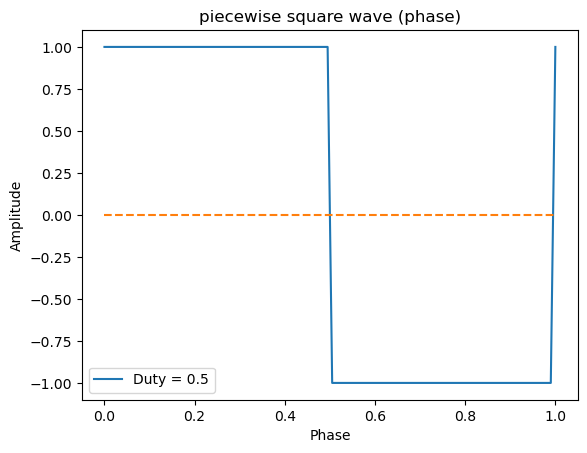

In [5]:
def square_wave_t (t, freq = 1.0, duty=0.5):
    val = np.zeros_like(t)
    phase = (2*np.pi*freq*t)
    for i in range(len(phase)):
        if phase[i] % (2*np.pi) <= (duty*(2*np.pi)):
            val[i] = 1
        else: val[i] = -1
    return val

def square_wave_phase (p, freq = 1.0, duty=0.5):
    val = np.zeros_like(p)
    for i in range(len(p)):
        if p[i] % (1) <= (duty):
            val[i] = 1
        else: val[i] = -1
    return val

t = np.linspace(0, 1, num=100)
p = np.linspace(0, 1, num=100)


plt.title("piecewise square wave (phase)")
plt.plot(p, square_wave_phase(p, freq = 1.0, duty = 0.5), label='Duty = 0.5')
# plt.plot(t, square_wave_t(t, duty = 0.25), label='Duty = 0.25', linestyle=":")
# plt.plot(t, square_wave_t(t, duty = 0.75), label='Duty = 0.75', linestyle="-.")
plt.plot(t, np.zeros_like(t), linestyle='--')
plt.xlabel('Phase')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


# plt.title("piecewise square wave (time)")
# plt.plot(t, square_wave_t(t, freq = 1.0, duty = 0.5), label='Duty = 0.5')
# # plt.plot(t, square_wave_t(t, duty = 0.25), label='Duty = 0.25', linestyle=":")
# # plt.plot(t, square_wave_t(t, duty = 0.75), label='Duty = 0.75', linestyle="-.")
# plt.plot(t, np.zeros_like(t), linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Amplitude')
# plt.legend()
# plt.show()

By introducing duty cycle, the wave is no longer normalized. For an even wave, the integral for each cycle equals to 0. This applies not only to square wave, but for sine wave as well. To normalize, we keep the maximum absolute amplitude (either maxima or minima) to 1, while adjusting the other values amplitude such that we have equal integral for the high phase and the low phase. This can be achieved with the following equation for $D\le 0.5$:
$$ x(\phi)=   \left\{
\begin{array}{ll}
      1 & , \phi \mod 1 \le D \\
      -(D/1-D)  & , \phi \mod 1 > D \\
\end{array} 
\right.  $$

or for $D \ge 0.5$
$$ x(\phi)=   \left\{
\begin{array}{ll}
      (D/1-D) & , \phi \mod 1 \le D \\
      1  & , \phi \mod 1 > D \\
\end{array} 
\right.  $$

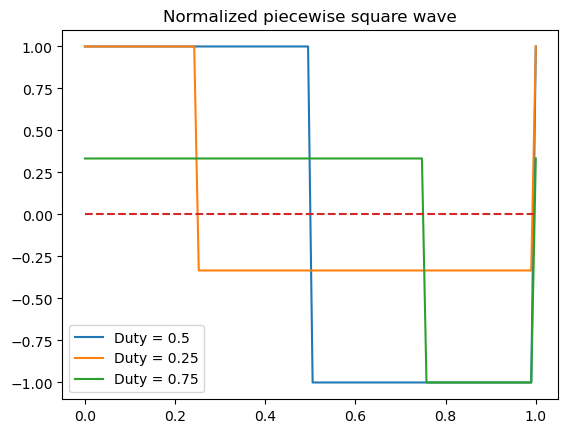

In [6]:
def square_wave_t_norm (t, freq = 1.0, duty=0.5):
    val = np.zeros_like(t)
    phase = (2*np.pi*freq*t)
    if duty <=0.5:
        for i in range(len(t)):
            if phase[i] % (2*np.pi) <= (duty*(2*np.pi)):
                val[i] = 1
            else: val[i] = (duty/(1-duty))*-1.0
    elif duty >0.5:
        for i in range(len(t)):
            if phase[i] % (2*np.pi) <= (duty*(2*np.pi)):
                val[i] = ((1-duty)/duty)*1.0
            else: val[i] = -1.0
    return val

t = np.linspace(0, 1, num=100)
plt.title("Normalized piecewise square wave")
plt.plot(t, square_wave_t_norm(t, duty = 0.5, freq=1), label='Duty = 0.5')
plt.plot(t, square_wave_t_norm(t, duty = 0.25, freq=1), label='Duty = 0.25')
plt.plot(t, square_wave_t_norm(t, duty = 0.75, freq=1), label='Duty = 0.75')
plt.plot(t, np.zeros_like(t), linestyle='--')
plt.legend()
plt.show()

### A.2 - Harmonics and Frequency space.

While this is a debatable sentiment, every sound is sine; a combination of infinitely many sine waves to be exact. One of the most common way to change waveform is to introduce harmonics to a base sine wave by adding the wave together, a process known as "additive synthesis." This website (https://meettechniek.info/additional/additive-synthesis.html) gives a good demonstration how harmonics affects a waveform and how different it sounds.

Square wave is the result of addition of sine waves. Take a look of the Fourier transformation of a sine wave and a square wave with 50% Duty cycle.

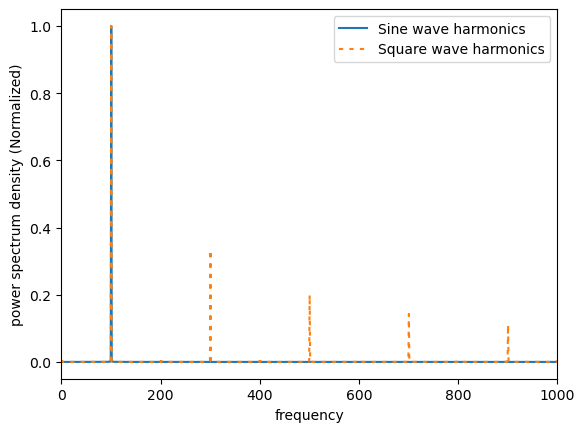

In [7]:
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy.fft import fftshift

def perform_fft (wave):

    wave_fft = fft(wave)
    wave_fft = fftshift(wave_fft)
    wave_fft = np.abs(wave_fft)
    wave_fft = wave_fft / np.max(wave_fft)

    return wave_fft

sample_rate = 44100
frequency = 100
time = 1

t = np.linspace(0, time, num = sample_rate*time)
pure_sine = sine_wave(t, freq=frequency)
pure_square= square_wave_t_norm(t, freq=frequency)

pure_sine_fft = perform_fft(pure_sine)
square_wave_fft = perform_fft(pure_square)

x_freq = np.linspace(-(1/(2))*sample_rate, (1/(2))*sample_rate, sample_rate*time)

plt.plot(x_freq, pure_sine_fft, label='Sine wave harmonics')
plt.plot(x_freq, square_wave_fft, label='Square wave harmonics', linestyle=(0, (2, 3)))
plt.legend()
plt.xlabel('frequency')
plt.ylabel('power spectrum density (Normalized)')
# plt.xlim(0, ((1/2)*sample_rate))
plt.xlim(0, 1000)
plt.show()

Sine wave only have the original tone (fundametal frequency) while square waves have additional harmonics of (n/2)+1 times of the fundamental. Taking a look at uneven square waves, we have the following

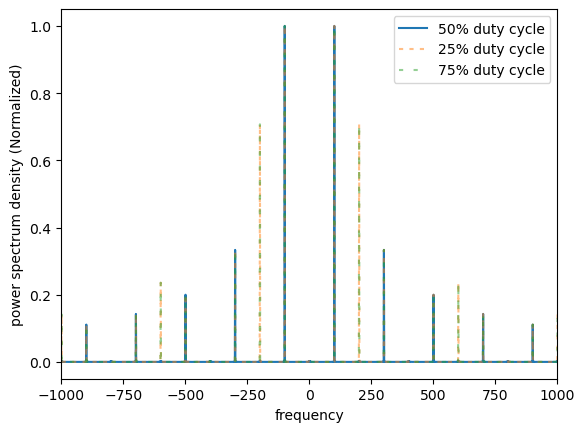

In [8]:
sample_rate = 44100
frequency = 100
time = 1

t = np.linspace(0, time, num = sample_rate*time)
square_50= square_wave_t_norm(t, freq=frequency, duty=0.5)
square_25= square_wave_t_norm(t, freq=frequency, duty=0.25)
square_75 = square_wave_t_norm(t, freq=frequency, duty = 0.75)

square_50_fft = perform_fft(square_50)
square_25_fft = perform_fft(square_25)
square_75_fft = perform_fft(square_75)

x_freq = np.linspace(-(1/(2))*sample_rate, (1/(2))*sample_rate, sample_rate*time)

plt.plot(x_freq, square_50_fft, label='50% duty cycle')
plt.plot(x_freq, square_25_fft, label='25% duty cycle', linestyle=(0, (2, 3)), alpha=0.5)
plt.plot(x_freq, square_75_fft, label='75% duty cycle', linestyle=(0, (2, 5)), alpha=0.5)
plt.legend()
plt.xlabel('frequency')
plt.ylabel('power spectrum density (Normalized)')
# plt.xlim(0, ((1/2)*sample_rate))
plt.xlim(-1000, 1000)
plt.show()

For uneven square wave, we have more harmonics. For 25% and 75% duty cycle, we have additional peaks happening for every 4th harmonics after the 2nd harmonics (2, 6, 10, ...). Different duty cycles give different harmonics. 

Also, notice that 25% and 75% duty cycles graph are overlapping. This visually shows that, both duty cycles are essentially the same in frequency space. Taking a look at the piecewise graph, square wave with 75% duty cycles are the inverse and shifted (by $\pi$) version of the 25% duty cycle square wave. In auditory sense, the two graph will sound the same (consider the sound of cos and sine wave). Take a listen of the following and try to spot the difference (if any):

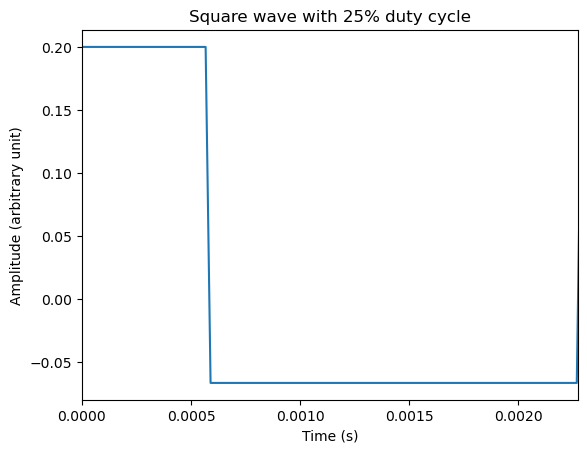

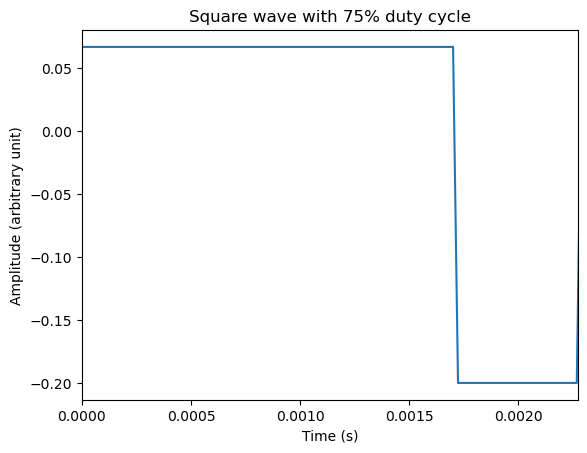

In [9]:
#[insert demo sound of 25% and 75% square wave]
sample_rate = 44100
frequency = 440
time = 3
amp_adjust = 0.20 #to adjust volume

t = np.linspace(0, time, num = sample_rate*time)
square_25= square_wave_t_norm(t, freq=frequency, duty=0.25)
square_75= square_wave_t_norm(t, freq=frequency, duty=0.75)

#adjust volume
square_25 = square_25 * amp_adjust
square_75 = square_75 * amp_adjust

#display 1 cycle
display_sound(square_25, cut_frame = [0, 1/frequency], title = 'Square wave with 25% duty cycle')
display_sound(square_75, cut_frame = [0, 1/frequency], title = 'Square wave with 75% duty cycle')

Generally, if the two square waves have the same residue of duty cycle from 50%, both square wave sound the same. Hence, we can simplify the square wave generator to only consider 0-50% duty cycle. This is what is done with the waveform generator in the `Image_sonification` module.

### A.3- Image sonification: Combining Color and Position.

This method of sonification attempts to represent a pixel's position and color parameter using one of the rarely used (as far as the author is aware of) method: Manipulating the timbre of a sound wave. 

Most of the image sonification method uses (relatively) arbitrary pickings of instruments to represent one or more parameters (see: [INPUT EXAMPLE HERE]). This method expands on the idea by exploring what makes different sounds in various musical instruments, culminating on eliminating the arbitrary choosings of musical instrument. On a whole image scale, we translate the following image as follows:

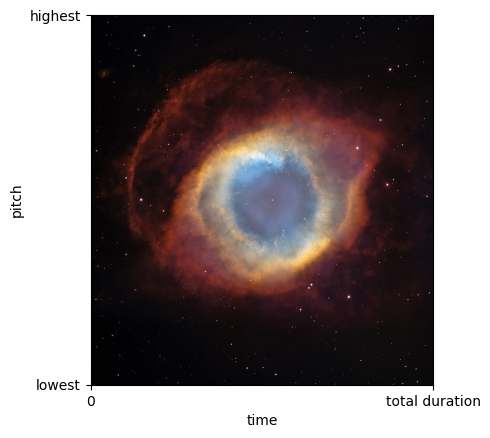

In [10]:
from skimage.io import imread

helix_image = imread("helix_nebula_test.jpg")
plt.imshow(helix_image)
plt.xticks(ticks=[0, len(helix_image[0])], labels=[0, 'total duration'])
plt.yticks(ticks=[0, len(helix_image)], labels=['highest', 'lowest'])
plt.xlabel('time')
plt.ylabel('pitch')
plt.show()

Duration and pitch scale are somewhat arbitrary. Variation of duration determines whether the intention is to take a short glance (short duration) or a detailed evaluation (long duration). Pitch scale, however, can be more rigorous considering available reviews. One can choose 125-1250 Hz sound as the pitch scale since it has relatively stable equal-loudness countour [CITE TRAYFORD HERE]. Or, one can choose a range to simulate a specific musical instrument, such as a classical piano with pitch range of A0 to C8.

In addition, it is wise to consider the resolution of sonification, both time and pitch. Whether we want an existing temprament of pitch, or how frequent the sound change. The `Image_sonification` module allows for customization of these parameters.

On a pixel scale, we use the extracted color information for each pixel to create different "instrument" by modifying a square wave. Using HSL color space:
1. Hue -> Duty cycle of a square wave
2. Saturation -> ???
3. Lightness -> Amplitude of wave -> volume.

note: The saturation translation is still a work in progress. It is planned that saturation is linked to a low-pass filter of the wave, yet an attempt to do this has been... less than fruitful.

While hue have periodic values (0 - 360; note that `OpenCV` uses 0 - 180 for Hue value while still maintaining periodicity [INSERT OPENCV LINK HERE]), our esthablished method of using duty cycle are not periodic (0 - 50%). We can exploit this, as this ensures that no two colors have same sound profile. We approach this from color in wavelength terms, since wavelength is not periodic. Equating Hue to wavelength, we found that we can use some range of wavelength [INSERT SOURCE]. In addition, a range of hue value does not have a wavelength correspondence, such as magenta. Hence, we eliminate this hue range. 

However, this method is a double-edged sword. While we can eliminate the position of 0% duty cycle that won't produce any sound, this makes the sonification method potentially useless to sonify magenta colors. This issue should be addressed later. However, for optical astronomy images, this elimination is somewhat non-consequential. The following is the range of hue and duty cycle used:

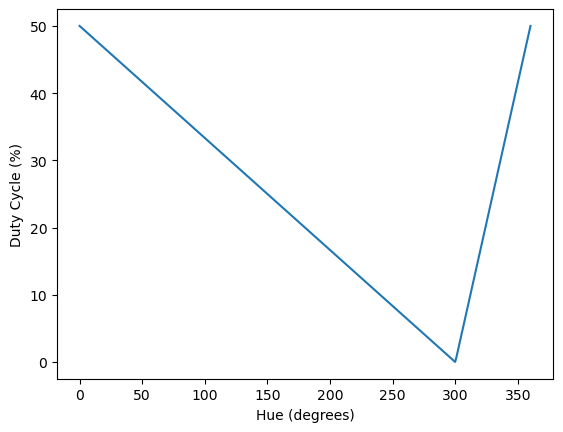

In [11]:
hue = np.linspace(0, 360, num=360)

duty_1 = lambda hue_1: 50-(hue_1/(2*300)*100)
duty_2 = lambda hue_2: ((hue_2-300)/(2*60)*100)

duty = np.where(hue <= 300, duty_1(hue), duty_2(hue))

plt.plot(hue, duty)
plt.xlabel('Hue (degrees)')
plt.ylabel('Duty Cycle (%)')
plt.show()

This Hue-Duty cycle correspondence is subject to change, as more literature gives a somewhat different way of equating them. In the future, this will be fixed with implementation of CIE 1931 convention. The principle still stands, however. Instead of complete removal of sound, we move the Duty Cycle other way around for the unavailable hue in nature.

If one prefers a generalized and not-necessarily-linear function forhue-duty correspondence this function may be used. This way, the duty equation for $hue \le cutoff$ :

$$ duty = \left(\frac{(-h+c)50^{1/d_1}}{c}\right)^{d_1} $$

and for $hue > cutoff$:

$$ duty = \left(\frac{(h-c)50^{1/d_2}}{h_{max}-c}\right)^{d_2} $$

where $h$ = hue, $c$ = hue cutoff, and $d_n$ = polynomial degree. 

Note that this polynomial degree before and after cutoff hue may differ. Additionally, consider the hue range. By default, the hue range should be $ 0 \le hue \le 360$. However, certain condition may require different hue range. For example, `OpenCV` modules uses hue range of $ 0 \le hue \le 180$.

C:\Users\deand\AppData\Local\Temp\ipykernel_133444\2290578756.py:23: RuntimeWarning: invalid value encountered in power
  np.power(duty_res1(hue_input, hue_cutoff, constant_poly1), poly_degree_1), \
C:\Users\deand\AppData\Local\Temp\ipykernel_133444\2290578756.py:24: RuntimeWarning: invalid value encountered in power
  np.power(duty_res2(hue_input, hue_cutoff, constant_poly2), poly_degree_2))


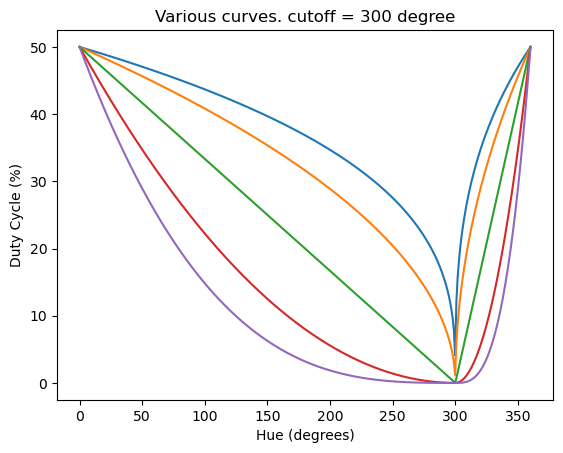

In [12]:
#is this chebyshev? probably not... but this is actually a nice series

#general equation for duty, will be checked
def duty_res1 (hue_input, hue_cutoff, constant):
    return ((-hue_input+hue_cutoff)*constant)/hue_cutoff
    
def duty_res2 (hue_input, hue_cutoff, constant):
    return ((hue_input-hue_cutoff)*constant)/(360-hue_cutoff)

def duty_fx (hue_input, hue_cutoff, poly_degree_1, poly_degree_2):
    
    constant_poly1 = np.power(50, 1/poly_degree_1)
    constant_poly2 = np.power(50, 1/poly_degree_2)

    # lambda cond_poly_1: True if 

    #to limit hue input 0 - 360, check whether it changes when shifted. Keep at 0-360
    #make a copy to the input does not change


    #construct general equation
    return np.where(hue_input <= hue_cutoff, \
                    np.power(duty_res1(hue_input, hue_cutoff, constant_poly1), poly_degree_1), \
                    np.power(duty_res2(hue_input, hue_cutoff, constant_poly2), poly_degree_2))


#check
hue = np.linspace(0, 360, num=360)

cutoff_hue = 300

#note that the polynomial degree may differ before and after cutoff
duty03 = duty_fx(hue, cutoff_hue, 0.333, 0.333)
duty05 = duty_fx(hue, cutoff_hue, 0.5, 0.5)
duty1 = duty_fx(hue, cutoff_hue, 1, 1)
duty2 = duty_fx(hue, cutoff_hue, 2, 2)
duty3 = duty_fx(hue, cutoff_hue, 3, 3)

plt.title(f'Various curves. cutoff = {cutoff_hue} degree')
plt.plot(hue, duty03, label= 'degree = 0.333')
plt.plot(hue, duty05, label= 'degree = 0.5')
plt.plot(hue, duty1, label= 'degree = 1')
plt.plot(hue, duty2, label= 'degree = 2')
plt.plot(hue, duty3, label= 'degree = 3')
plt.xlabel('Hue (degrees)')
plt.ylabel('Duty Cycle (%)')
# plt.legend()
plt.show()

Some literature does not consider hue value from 0 to around 10 to have a wavelength equivalent. Some literature also consider other value of hue to be the maximum hue. Finally, one might want to control maximum and minimum duty value. Hence, these generalized functions allow for maximum control of those parameters. To further simplify equation, we consider the non-negative input hue angle of $ 0\le h_{inp} \le h_{max}$

For value less than the low cutoff $h_{inp} \le C_{low}$:
$$duty = \left(\frac{(-(C_{high}-h_{inp})+h_{max})(D_{max}-D_{min})^{1/P_1}}{h_{max}-(C_{high}-C_{low})}\right)^{P_1}+D_{min}$$

For value inside the hue range $C_{low} \le h_{inp} \le C_{high}$ :
$$duty = \left(\frac{(C_{high}-h_{inp})(D_{max}-D_{min})^{1/P_1}}{(C_{high}-C_{low})}\right)^{P_1}+D_{min}$$

For value greater than high cutoff $h_{inp} \ge C_{high}$:
$$duty = \left(\frac{-(C_{high}-h_{inp})(D_{max}-D_{min})^{1/P_1}}{h_{max}-(C_{high}-C_{low})}\right)^{P_1}+D_{min}$$


C:\Users\deand\AppData\Local\Temp\ipykernel_133444\2164858690.py:49: RuntimeWarning: invalid value encountered in power
  (np.power(duty_res2(hue_calculate, hue_cutoff_high, hue_cutoff_low, constant_poly2, hue_max), poly_degree_2)))


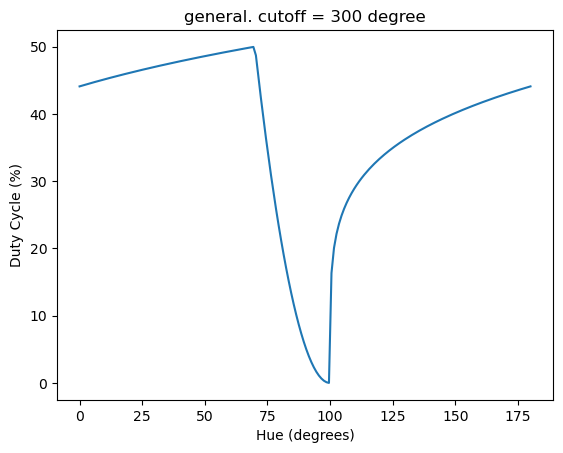

min value = 0.011096893216676736
max value = 49.95896435564945
max value = 180.0


In [134]:
def duty_res1 (hue_input, cutoff_high, cutoff_low, constant):
    return ((cutoff_high-hue_input)*constant)/(cutoff_high - cutoff_low)
    
def duty_res2 (hue_input, cutoff_high, cutoff_low, constant, max_val=360):
    return (-(cutoff_high-hue_input)*constant)/(max_val-(cutoff_high - cutoff_low))



def duty_fx_range (hue_input, #should modify this for nonarray usage
                   hue_cutoff_low, 
                   hue_cutoff_high,
                   hue_max = 360, 
                   duty_min = 0, 
                   duty_max = 50, 
                   poly_degree_1=1, 
                   poly_degree_2=1, 
                   invert = False):

    #redefine terminology
    hue_shift = hue_cutoff_low
    hue_range = hue_cutoff_high - hue_cutoff_low #range for upper cutoff
    
    #start the trick
    hue_calculate = hue_input.copy()

    try: #default calculation for nonarray input
        #check if hue_calculate is within hue = [0, hue_max]. if not, wrap the value by +/- hue_max
        hue_calculate = hue_calculate + hue_max if hue_calculate < hue_cutoff_low else hue_calculate
    
        if hue_calculate <= hue_cutoff_high:
            constant_poly = np.power((duty_max - duty_min), 1/poly_degree_1)
            duty_val = np.power(duty_res1(hue_calculate, hue_cutoff_high, hue_cutoff_low, constant_poly), poly_degree_1)
    
        else: 
            constant_poly = np.power((duty_max - duty_min), 1/poly_degree_2)
            duty_val = np.power(duty_res2(hue_calculate, hue_cutoff_high, hue_cutoff_low, constant_poly, hue_max), poly_degree_2)


    
    except ValueError:        #if array
        for i in range(len (hue_calculate)):
            hue_calculate[i] = hue_calculate[i] + hue_max if (hue_calculate[i] <hue_cutoff_low) else hue_calculate[i]
    
        constant_poly1 = np.power((duty_max - duty_min), 1/poly_degree_1)
        constant_poly2 = np.power((duty_max - duty_min), 1/poly_degree_2)
    
        duty_val = np.where(hue_calculate <= hue_cutoff_high, \
                            (np.power(duty_res1(hue_calculate, hue_cutoff_high, hue_cutoff_low, constant_poly1), poly_degree_1)),
                            (np.power(duty_res2(hue_calculate, hue_cutoff_high, hue_cutoff_low, constant_poly2, hue_max), poly_degree_2)))

    
    if invert:
        return -(duty_val+duty_min) + duty_max
    else:
        return duty_val+duty_min
    

#check

hue_max = 180
hue = np.linspace(0, hue_max, num=180)

duty2 = duty_fx_range(hue, #should modify this for nonarray usage
                   hue_cutoff_low = 70, 
                   hue_cutoff_high = 100,
                   hue_max = hue_max, 
                   duty_min = 0, 
                   duty_max = 50, 
                   poly_degree_1=2, 
                   poly_degree_2=0.2, 
                   invert = False)
 
#note that the polynomial degree may differ before and after cutoff

plt.title(f'general. cutoff = {cutoff_hue_high} degree')
plt.plot(hue, duty2, label= 'degree = 1')
plt.xlabel('Hue (degrees)')
plt.ylabel('Duty Cycle (%)')

# plt.ylim(0, 50)
plt.show()
print (f'min value = {np.min(duty2)}')
print (f'max value = {np.max(duty2)}')
print (f'max value = {np.max(hue)}')

## Part B - Image Sonification Tutorial

After the glimpse of the method, let's jump into the tutorial!

### B.1 - Image processing

#### B.1.1 - Reading an image

Let's read an image first with the `Image_read` function. On the module, we have 2 images:
1. Saturn image
2. Helix nebula image

`Image_read` function returns an object with `Image_read` class, reading the given image as an object. Let's see this function in action and check the attributes on the class

Reading helix_nebula_test.jpg

height
width
aspect_ratio
image_rgb
image_hls
image_grey
width_old
height_old
aspect_ratio_old
image_rgb_old
image_hls_old
image_grey_old



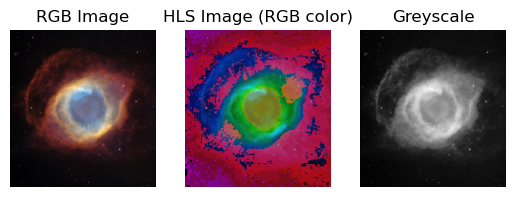

In [15]:
#importing the custom Reader from this module
from Reader import Image_read


helix_image = Image_read("helix_nebula_test.jpg", message = True)

#checking attributes
base_attributes = list(helix_image.__dict__.keys())

print()
for n in range(len(base_attributes)):
    print (base_attributes[n])
print()
#show the image
fig, axs = plt.subplots(1, 3)
axs[0].set_axis_off()
axs[0].imshow(helix_image.image_rgb)
axs[0].set_title('RGB Image')

axs[1].set_axis_off()
axs[1].imshow(helix_image.image_hls)
axs[1].set_title('HLS Image (RGB color)')

axs[2].set_axis_off()
axs[2].imshow(helix_image.image_grey, cmap='Greys_r')
axs[2].set_title('Greyscale')

plt.show()

Ignore the attributes with `_old` suffix. This is used for restoring the image to its original state.

Notice that the first three attributes refers to the image dimension parameters, while the other three is the image in three color spaces (RGB, HLS, an greyscale). RGB is the default color space for showing and reading image for `matplotlib` and `OpenCV`. We convert this image into HLS and Greyscale. Greyscale image will be used for thresholding. The reason why HLS is used in favor of HSV is due to the sonification method used (we'll dive into this later).

Before going forward, We have to adjust the size of the image first. This adjustment is needed to determine the range and resolution of duration and frequency range of the sonification. `Oscillator_simple` submodule have a function to generate an array of frequency for our sonification. By default, it will generate 88 frequencies tuned with 12-TET similar to classical piano. 

Then, we resize the image to have 88 pixel height (at least the number as the frequency list), while adjusting the width to preserve its aspect ratio

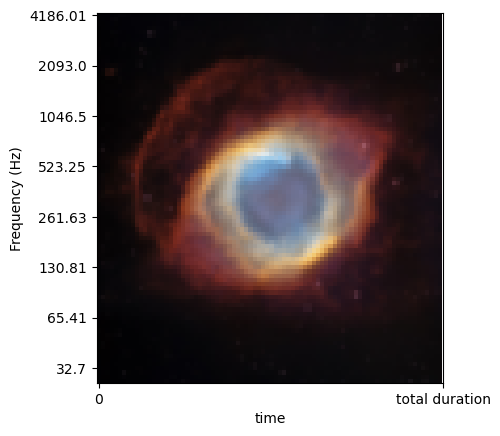

In [16]:
from Oscillator_simple import frequency_gen
frequency_list = frequency_gen()

helix_image.resize(height=len(frequency_list), aspect_preserve=True)
plt.imshow(helix_image.image_rgb)
plt.xticks(ticks=[0, len(helix_image.image_rgb[0])], labels=[0, 'total duration'])
plt.yticks(ticks=np.arange(0, len(frequency_list), 12),labels=np.round(frequency_list[::12],2))
plt.xlabel('time')
plt.ylabel('Frequency (Hz)')
plt.show()

Keep in mind that the `.resize` procedure and `frequency_gen` function are customizable.

#### B.1.2 - Thresholding - Global and Local

To identify which pixel are objects and which pixel are background, we will use a technique called thresholding. `OpenCV` tutorial (https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html) gives two methods of thresholding: 

1. adaptive (which we'll call local), mainly for object outline
2. global thresholding, for object fill.

We can create a boolean mask for both thresholding, and we'll see the difference

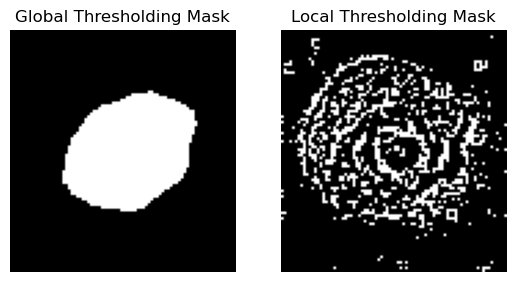

In [17]:
helix_global_mask, helix_local_mask = helix_image.threshold_mask()
fig, axs = plt.subplots(1, 2)
axs[0].set_axis_off()
axs[0].imshow(helix_global_mask, cmap='Greys')
axs[0].set_title('Global Thresholding Mask')

axs[1].set_axis_off()
axs[1].imshow(helix_local_mask, cmap='Greys')
axs[1].set_title('Local Thresholding Mask')

plt.show()

If one is not satisfied with the thresholding mask, we can fine-tune the parameters for the mask with arrays of 1 (for global thresholding) or 3 (for local thresholding) element(s). 

The only element of global thresholding tuning array and the first element of local thresholding tuning array deal with blurring. This blurring is needed to reduce noise. The default value of blurring is 1.

Local thresholding only considers the local surrounding pixel, not the whole image. The 2nd parameters determines the area of the surrounding pixel. The 3rd element determines a constant that is used to subtract the value of the evaluation.

Every image is different. Fine-tuning both of this thresholding mask is encouraged. For now, let's go ahead to threshold the image with default mask.

performing image threshold in Grayscale, HLS, and RGB color space


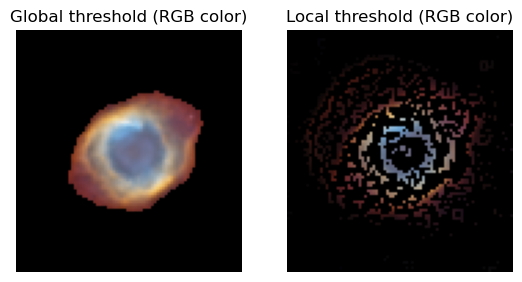

In [18]:
# thresholding the image
helix_image.threshold(local_mask = helix_local_mask, global_mask = helix_global_mask, message=True)

fig, axs = plt.subplots(1, 2)
axs[0].set_axis_off()
axs[0].imshow(helix_image.image_rgb_global_threshold)
axs[0].set_title('Global threshold (RGB color)')

axs[1].set_axis_off()
axs[1].imshow(helix_image.image_rgb_local_threshold)
axs[1].set_title('Local threshold (RGB color)')

plt.show()

notice that in the above function, the image threshold is saved in the following attributes
`.image_{COLOR SPACE}_{GLOBAL/LOCAL}_threshold`

### B.2 - Sonifying

We have the thresholded image, both global and local. To simplify, put both thresholded image (in HLS space) into two different variables, and we can separate each channel (Hue, Saturation, and Lightness) to three different channels. After that, we max-normalize saturation and lightness channel

In [19]:
image_global_threshold = helix_image.image_hls_global_threshold
image_global_threshold_hue = image_global_threshold[:, :, 0]

image_global_threshold_lightness = image_global_threshold[:, :, 1]
image_global_threshold_lightness = image_global_threshold_lightness/np.max(image_global_threshold_lightness)

image_global_threshold_saturation = image_global_threshold[:, :, 2]
image_global_threshold_saturation = image_global_threshold_saturation/np.max(image_global_threshold_saturation)


image_local_threshold = helix_image.image_hls_local_threshold
image_local_threshold_hue = image_local_threshold[:, :, 0]

image_local_threshold_lightness = image_local_threshold[:, :, 1]
image_local_threshold_lightness = image_local_threshold_lightness/np.max(image_local_threshold_lightness)

image_local_threshold_saturation = image_local_threshold[:, :, 2]
image_local_threshold_saturation = image_local_threshold_saturation/np.max(image_local_threshold_saturation)

Now, we perform the sonification!

note: I should put this into a single function, this is still a WIP

In [20]:
from Oscillator_simple import Oscillator
from Oscillator_simple import frequency_gen
from Oscillator_simple import generate_sample
# from Oscillator_simple import saturation_lowpass  #deprecating lowpass
from Oscillator_simple import saturation_frequency
from tqdm import tqdm

In [21]:
# sample parameters
sample_rate = 44100
time = 0.1 #(0.1 second for each horizontal pixel

total_wave_local = np.zeros(int(sample_rate*time*len(image_local_threshold_hue[0])))
total_wave_global = np.zeros(int(sample_rate*time*len(image_global_threshold_hue[0])))

In [22]:
#sonifying the local threshold
for h in tqdm(range(len(image_local_threshold_hue))):
        
    init_phase = 0     
    generator_arr_norm = np.zeros(0)
    for w in (range(len(image_local_threshold_hue[h]))):
        if image_local_threshold_hue[h, w]<=150: #remember, openCV hue ranges from 0 - 180, half of usual
            duty = 0.5-(image_local_threshold_hue[h, w]/(2*150))
        elif image_local_threshold_hue[h, w]>150:
            duty = ((image_local_threshold_hue[h, w]-150)/(2*30))
                
            #need trick, if lightness value = 0, then just generate 0 value immediately!
            # hopefully quicken the generator -> something's different... phase?
        if image_local_threshold_lightness[h,w] == 0: #change to switch?
            gen_points_norm = np.zeros(int(sample_rate*time))
            init_phase = 0 
            
        else:
            base_wave_gen = Oscillator(waveform='square_norm', freq=frequency_list[h], rate=44100, duty=duty, phase=init_phase)
            base_wave = np.array(generate_sample(base_wave_gen, time=time)) 
            # gen_points_norm = saturation_lowpass(gen_points_norm, image_local_threshold_saturation[h, w], frequency_list[h])

            inharmonic_wave_freq = saturation_frequency(image_local_threshold_saturation[h, w], frequency_list[h], frequency_list)
            inharmonic_wave_gen = Oscillator(waveform='square_norm', freq=inharmonic_wave_freq, rate = 44100, duty=duty, phase=init_phase)
            inharmonic_wave = np.array(generate_sample(inharmonic_wave_gen, time=time)) 

            inharmonic_wave = inharmonic_wave *0.1

            gen_points_norm = base_wave + inharmonic_wave
            gen_points_norm = (gen_points_norm)*image_local_threshold_lightness[h, w]
                
            init_phase = base_wave_gen.phase # should be the same with normalized and non-normalized
            
        generator_arr_norm = np.concatenate((generator_arr_norm, gen_points_norm), axis=None)
        
    total_wave_local = total_wave_local+generator_arr_norm
    
total_wave_local = total_wave_local/np.max(abs(total_wave_local))

100%|██████████████████████████████████████████████████████████████████████████████████| 88/88 [00:09<00:00,  9.53it/s]


In [23]:
#sonifying the global threshold
for h in tqdm(range(len(image_global_threshold_hue))):
        
    init_phase = 0     
    generator_arr_norm = np.zeros(0)
    for w in (range(len(image_global_threshold_hue[h]))):
        if image_global_threshold_hue[h, w]<=150: #remember, openCV hue ranges from 0 - 180, half of usual
            duty = 0.5-(image_global_threshold_hue[h, w]/(2*150))
        elif image_global_threshold_hue[h, w]>150:
            duty = ((image_global_threshold_hue[h, w]-150)/(2*30))
                
            #need trick, if lightness value = 0, then just generate 0 value immediately!
            # hopefully quicken the generator -> something's different... phase?
        if image_global_threshold_lightness[h,w] == 0: #change to switch?
            gen_points_norm = np.zeros(int(sample_rate*time))
            init_phase = 0 
            
        else:
            sq_gen_norm = Oscillator(waveform='square_norm', freq=frequency_list[h], rate=44100, duty=duty, phase=init_phase)
            gen_points_norm = np.array(generate_sample(sq_gen_norm, time=time)) 
            # gen_points_norm = saturation_lowpass(gen_points_norm, image_global_threshold_saturation[h, w], frequency_list[h])
            gen_points_norm = (gen_points_norm)*image_global_threshold_lightness[h, w]
                
            init_phase = sq_gen_norm.phase # should be the same with normalized and non-normalized
            
        generator_arr_norm = np.concatenate((generator_arr_norm, gen_points_norm), axis=None)
        
    total_wave_global = total_wave_global+generator_arr_norm
    
total_wave_global = total_wave_global/np.max(abs(total_wave_global))
total_wave_global = total_wave_global * 0.25 #adjust global volume

100%|██████████████████████████████████████████████████████████████████████████████████| 88/88 [00:06<00:00, 13.30it/s]


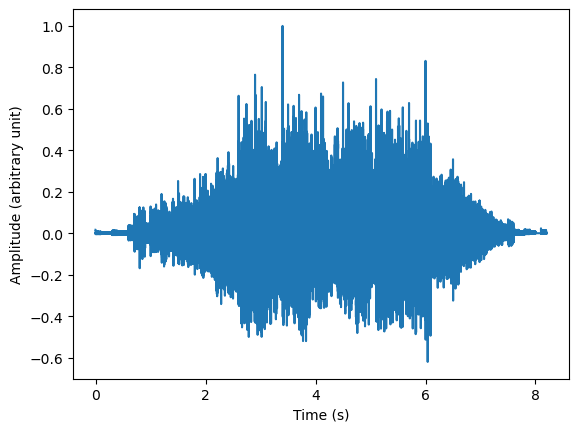

In [24]:
total_sound = total_wave_global + total_wave_local
total_sound = total_sound/np.max(abs(total_sound))

display_sound(total_sound)

In [25]:
h = 10
w = 10

inharmonic_wave_freq = saturation_frequency(image_local_threshold_saturation[h, w], frequency_list[h], frequency_list)
print (inharmonic_wave_freq)
# inharmonic_wave_gen = Oscillator(waveform='square_norm', freq=inharmonic_wave_freq, rate = 44100, duty=duty, phase=init_phase)
# inharmonic_wave = np.array(generate_sample(inharmonic_wave_gen, time=time)) 

2400.740619328483
